### Phase 2 - Step 1: Environment Setup & Data Pipeline Tools
This step imports all necessary libraries, defines parameters, and constructs the classes and functions required for robust DataLoading. We handle loading the arrays from pickles and properly splitting them into Train/Val/Test subsets.

In [2]:
import os
import copy
from pathlib import Path
from typing import Literal, Tuple, Optional, List, Dict, Iterable

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, roc_curve, auc, 
                             precision_recall_curve, average_precision_score)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# --------------------------------------------------------------------------- #
# Core Configurations
# --------------------------------------------------------------------------- #
WALLS_PKL = Path("wall_data.pkl")
DECKS_PKL = Path("deck_data.pkl")
LABEL_MAP = {"Non-Cracked": 0, "Cracked": 1}

# Create a checkpoint directory to hold the three separate models
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

# --------------------------------------------------------------------------- #
# Data Loaders & Splitting definitions
# --------------------------------------------------------------------------- #
def load_dataframe(domain: Literal["walls", "decks", "both"] = "both") -> pd.DataFrame:
    dfs = []
    if domain in ("walls", "both"):       dfs.append(pd.read_pickle(WALLS_PKL))
    if domain in ("decks", "both"):       dfs.append(pd.read_pickle(DECKS_PKL))
    if not dfs: raise ValueError("No dataframes loaded.")
    
    df = pd.concat(dfs, axis=0, ignore_index=True)
    df["Label"] = df["Label"].map(LABEL_MAP)
    return df

def stratified_splits(df: pd.DataFrame, train_size=0.7, val_size=0.15, test_size=0.15, random_state=42):
    train_df, temp_df = train_test_split(df, train_size=train_size, stratify=df["Label"], random_state=random_state, shuffle=True)
    val_fraction = val_size / (val_size + test_size)
    val_df, test_df = train_test_split(temp_df, train_size=val_fraction, stratify=temp_df["Label"], random_state=random_state, shuffle=True)
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

class CrackDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform: Optional[transforms.Compose] = None):
        self.df = df
        self.transform = transform

    def __len__(self) -> int: return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img_np = row["ImageData"]
        if img_np.dtype != np.uint8: img_np = img_np.astype(np.uint8)
        img_pil = Image.fromarray(img_np)
        label = int(row["Label"])
        return self.transform(img_pil) if self.transform else transforms.ToTensor()(img_pil), label

# Transforms
imagenet_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_transform = transforms.Compose([transforms.RandomHorizontalFlip(p=0.5), transforms.RandomVerticalFlip(p=0.5), transforms.ToTensor(), imagenet_norm])
eval_transform = transforms.Compose([transforms.ToTensor(), imagenet_norm])

def build_dataloaders(domain: Literal["walls", "decks", "both"] = "both", batch_size: int = 32, num_workers: int = 0):
    df = load_dataframe(domain=domain)
    train_df, val_df, test_df = stratified_splits(df)
    train_dl = DataLoader(CrackDataset(train_df, train_transform), batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_dl = DataLoader(CrackDataset(val_df, eval_transform), batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_dl = DataLoader(CrackDataset(test_df, eval_transform), batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_dl, val_dl, test_dl


### Phase 2 - Step 2: Model Architecture Engine
Generates Transfer Learning Models (ResNet50 / VGG16). Critically, it accurately locks the shallow feature parameters, reducing computation while preventing pre-trained catastrophic forgetting.

In [3]:
def build_model(model_name: str = "resnet50", freeze_early: bool = True, out_features: int = 1) -> nn.Module:
    """
    Build a transfer learning model and replace the final head for binary classification.
    """
    model_name = model_name.lower()
    if model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        in_feats = model.fc.in_features
        model.fc = nn.Linear(in_feats, out_features)
        
        # Safely freeze early feature extractors
        if freeze_early:
            for block in [model.conv1, model.bn1, model.layer1]:
                for param in block.parameters():
                    param.requires_grad = False
                    
    elif model_name == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        in_feats = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_feats, out_features)
        
        if freeze_early:
            for layer in list(model.features.children())[:10]:
                for param in layer.parameters():
                    param.requires_grad = False
    else:
        raise ValueError("Unsupported model; choose 'resnet50' or 'vgg16'.")

    return model


### Phase 2 - Step 3: Refactored Robust Training Loop 
Reintroduces the Pos_weight capability for class imbalance handling and retains our comprehensive Early Stopping and Metric tracking mechanisms.

In [4]:
def train_model_pipeline(
    model: nn.Module, 
    train_loader: DataLoader, 
    val_loader: DataLoader, 
    device: torch.device,
    save_path: str,
    epochs: int = 50, 
    lr: float = 1e-4, 
    patience: int = 6,
    pos_weight_val: Optional[float] = None
) -> Dict:
    """
    Unified training engine integrated with Learning Rate Scheduler and Early Stopping.
    """
    model = model.to(device)
    
    # Restored: Support for Class Imbalance Penalty
    if pos_weight_val is not None:
        pos_weight = torch.tensor([pos_weight_val]).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.BCEWithLogitsLoss()
    
    # Only pass active parameters to Optimizer
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=lr)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = []
    
    print(f"--- Training Sequence Initiated. Output: {save_path} ---")

    for epoch in range(1, epochs + 1):
        # ------------------ Training Phase ------------------
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            
        train_loss /= len(train_loader.dataset)
        
        # ------------------ Validation Phase ------------------
        model.eval()
        val_loss = 0.0
        all_targets, all_preds = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)

                logits = model(images)
                loss = criterion(logits, labels)
                val_loss += loss.item() * images.size(0)

                probs = torch.sigmoid(logits).squeeze(1)
                preds = (probs >= 0.5).long()
                all_targets.extend(labels.squeeze(1).cpu().numpy().tolist())
                all_preds.extend(preds.cpu().numpy().tolist())

        val_loss /= len(val_loader.dataset)
        rec = recall_score(all_targets, all_preds, zero_division=0)
        
        history.append({"epoch": epoch, "val_loss": val_loss})
        scheduler.step(val_loss)
        
        # Save mechanism
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            status_flag = "[✓ BEST SAVED]"
        else:
            epochs_no_improve += 1
            status_flag = f"[! NO IMP: {epochs_no_improve}/{patience}]"
            
        print(f"Epoch {epoch:03d}/{epochs} | T-Loss: {train_loss:.4f} | V-Loss: {val_loss:.4f} | V-Rec: {rec:.4f} {status_flag}")

        # Early Stopping Execute
        if epochs_no_improve >= patience:
            print(f"====== Early Stopping Triggered at Epoch {epoch} ! ======")
            break

    # Restore ultimate weights automatically before function end
    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    return history


### Phase 2 - Step 4: Multi-Domain Automated Training & Caching Sequence
In this loop, execution strictly filters datasets and handles checkpoint caching securely. If a .pth model file already exists for a domain, it cleanly skips the extensive epoch iterations to save computational resource while loading dataloaders for the inference phase.

In [5]:
# Hardware Config
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Hardware Compute Engine initialized onto: {device}\n")

domains_to_train = ["walls", "decks", "both"]
pipelines_artifacts = {}

for domain in domains_to_train:
    print(f"\n============================================================")
    print(f" PROCESSING PIPELINE FOR DOMAIN: {domain.upper()}")
    print(f"============================================================")
    
    param_path = CHECKPOINT_DIR / f"v3_best_model_{domain}.pth"
    train_dl, val_dl, test_dl = build_dataloaders(domain=domain, batch_size=32)
    
    model = build_model(model_name="resnet50", freeze_early=True).to(device)
    
    # Restored Logic: OS Path checking to bypass hours of redundant training
    if os.path.exists(param_path):
        print(f" Info: Detected existing pretrained artifact `{param_path.name}`.")
        print('Skipping extensive Epoch loop and securing pre-trained knowledge base...')
        
    else:
        print('Initiating Deep Training sequences...')
        train_model_pipeline(
            model=model, 
            train_loader=train_dl, 
            val_loader=val_dl, 
            device=device,
            save_path=str(param_path),
            epochs=50,       
            patience=6,
            lr=1e-4,
            pos_weight_val=None  # Adjust to float (e.g. 1.5) if specific domain False Negatives are excessively high
        )
    
    # Persist the necessary configurations to dictionary logic
    pipelines_artifacts[domain] = {
        "model_path": str(param_path),
        "test_dl": test_dl
    }


Hardware Compute Engine initialized onto: cuda


 PROCESSING PIPELINE FOR DOMAIN: WALLS
 Info: Detected existing pretrained artifact `v3_best_model_walls.pth`.
Skipping extensive Epoch loop and securing pre-trained knowledge base...

 PROCESSING PIPELINE FOR DOMAIN: DECKS
 Info: Detected existing pretrained artifact `v3_best_model_decks.pth`.
Skipping extensive Epoch loop and securing pre-trained knowledge base...

 PROCESSING PIPELINE FOR DOMAIN: BOTH
 Info: Detected existing pretrained artifact `v3_best_model_both.pth`.
Skipping extensive Epoch loop and securing pre-trained knowledge base...


### Phase 2 - Step 5: Independent Evaluation Suite & Enhanced Visualizations
Calculates extensive analytical metrics. Upgraded to generate a comprehensive 2x2 subplot matrix featuring Both Raw Tracking (Absolute counts) and Normalized Tracking (Percentages), alongside standard ROC AUC and critically crucial Precision-Recall (PR) Curves for heavily imbalanced defect detection thresholds.

In [6]:
def load_and_evaluate(pretrained_model_path: str, test_dataloader, device: torch.device):
    """
    Evaluates dataset on test_dataloader using pre-trained path strings securely.
    """
    eval_model = build_model("resnet50", freeze_early=True).to(device)
    eval_model.load_state_dict(torch.load(pretrained_model_path, map_location=device, weights_only=True))
    eval_model.eval()
    
    targets, probs = [], []
    with torch.no_grad():
        for images, labels in test_dataloader:
            images = images.to(device)
            logits = eval_model(images)
            p = torch.sigmoid(logits).squeeze(1)
            targets.extend(labels.cpu().numpy().tolist())
            probs.extend(p.cpu().numpy().tolist())
            
    return np.array(targets), np.array(probs)

def plot_comprehensive_analytics(targets: np.ndarray, probs: np.ndarray, preds: np.ndarray, domain_name: str):
    """
    Generates a 4-panel dashboard containing absolute counts, error distributions, and diagnostic curves.
    """
    # 1. Matrices Pre-calculation
    cm_raw = confusion_matrix(targets, preds)
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True).clip(min=1e-9)
    
    # 2. Curves Pre-calculation
    fpr, tpr, _ = roc_curve(targets, probs)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(targets, probs)
    pr_auc = average_precision_score(targets, probs)
    
    # 3. Figure Initialization (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    ax1, ax2, ax3, ax4 = axes.flatten()
    
    # --- Top-Left: Raw Confusion Matrix ---
    sns.heatmap(cm_raw, annot=True, fmt="d", cmap="Blues", ax=ax1,
                xticklabels=['Non-Cracked', 'Cracked'], yticklabels=['Non-Cracked', 'Cracked'])
    ax1.set_title(f"[{domain_name.upper()}] Raw Confusion Matrix")
    ax1.set_xlabel("AI Predicted (Count)")
    ax1.set_ylabel("True Annotations (Count)")
    
    # --- Top-Right: Normalized Confusion Matrix ---
    sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Reds", ax=ax2,
                xticklabels=['Non-Cracked', 'Cracked'], yticklabels=['Non-Cracked', 'Cracked'])
    ax2.set_title(f"[{domain_name.upper()}] Normalized Error Matrix")
    ax2.set_xlabel("AI Predicted (%)")
    ax2.set_ylabel("True Annotations (%)")
    
    # --- Bottom-Left: ROC Curve ---
    ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax3.set_xlim([0.0, 1.0])
    ax3.set_ylim([0.0, 1.05])
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate (Recall)')
    ax3.set_title('ROC Curve')
    ax3.legend(loc="lower right")
    ax3.grid(alpha=0.3)
    
    # --- Bottom-Right: Precision-Recall Curve ---
    ax4.plot(recall, precision, color='purple', lw=2, label=f'Avg Precision = {pr_auc:.3f}')
    ax4.set_xlim([0.0, 1.0])
    ax4.set_ylim([0.0, 1.05])
    ax4.set_xlabel('Recall (Sensitivity)')
    ax4.set_ylabel('Precision')
    ax4.set_title('Precision-Recall (PR) Curve')
    ax4.legend(loc="lower left")
    ax4.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


### Phase 2 - Step 6: Multi-Model Inference Reporting Hub
Initiates our extreme structural safety thresholds constraints and executes quantitative + visual rendering for our 3 unique AI models across respective test datasets.

INITIATING FINAL PHASE CROSS-DOMAIN CHECK SUMMARY:

COMPREHENSIVE PERFORMANCE REPORT: WALLS DATASET
Text-based Quality Metrics Extraction:
              precision    recall  f1-score   support

 Non-Cracked     0.9646    0.8713    0.9156      2129
     Cracked     0.6432    0.8790    0.7429       562

    accuracy                         0.8729      2691
   macro avg     0.8039    0.8752    0.8292      2691
weighted avg     0.8975    0.8729    0.8795      2691



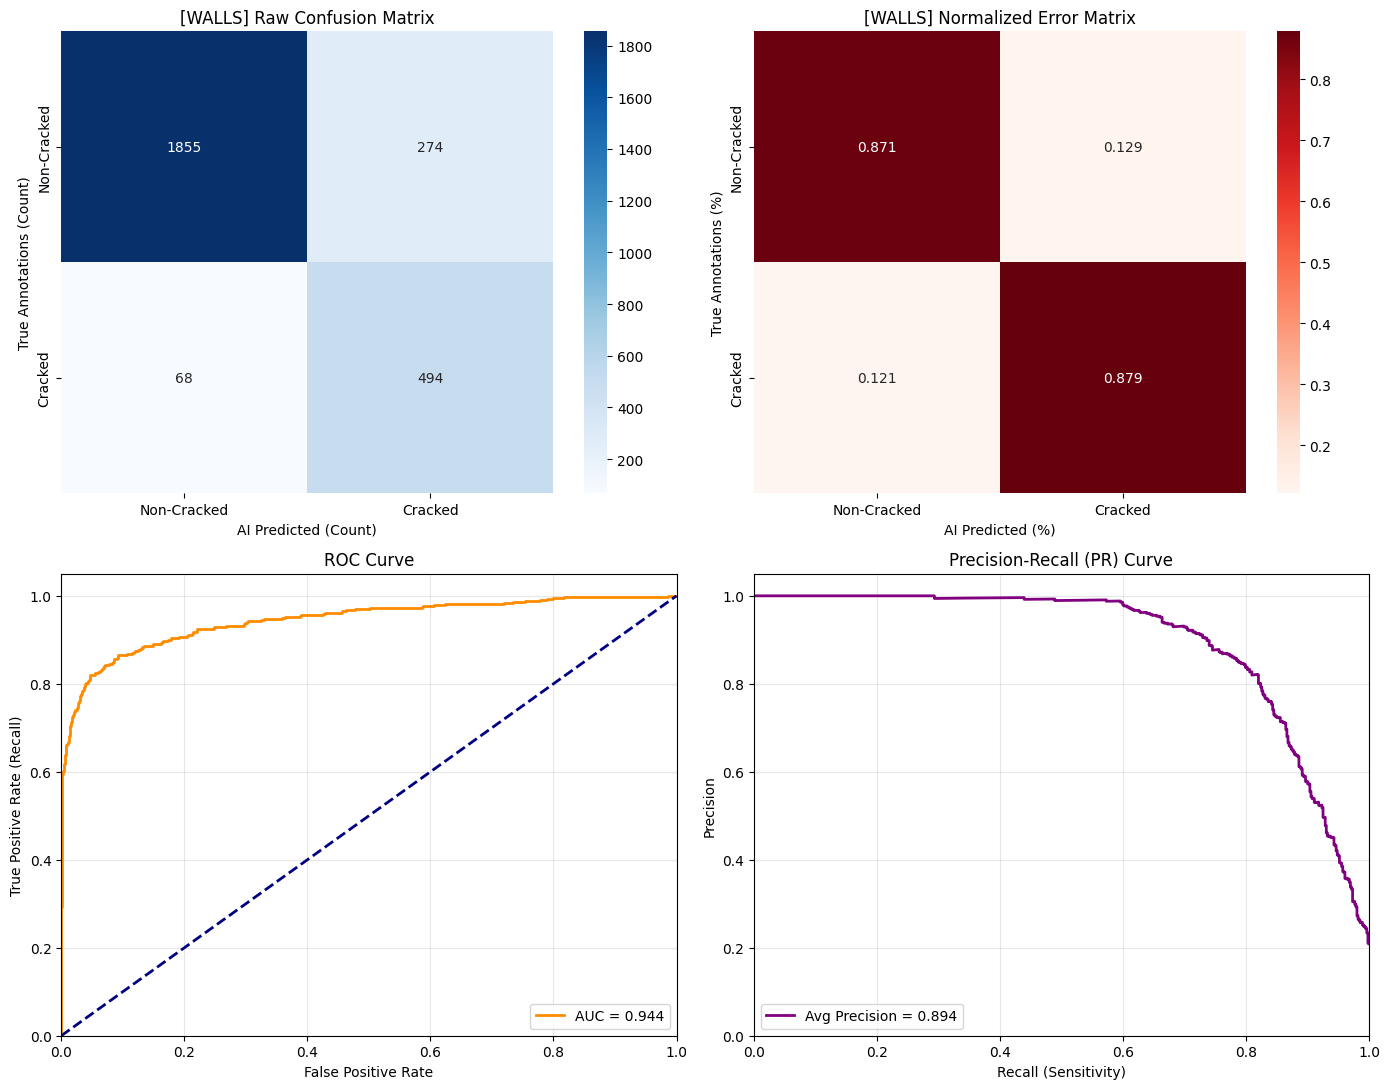


COMPREHENSIVE PERFORMANCE REPORT: DECKS DATASET
Text-based Quality Metrics Extraction:
              precision    recall  f1-score   support

 Non-Cracked     0.9588    0.8638    0.9088      1725
     Cracked     0.4891    0.7785    0.6008       289

    accuracy                         0.8515      2014
   macro avg     0.7240    0.8212    0.7548      2014
weighted avg     0.8914    0.8515    0.8646      2014



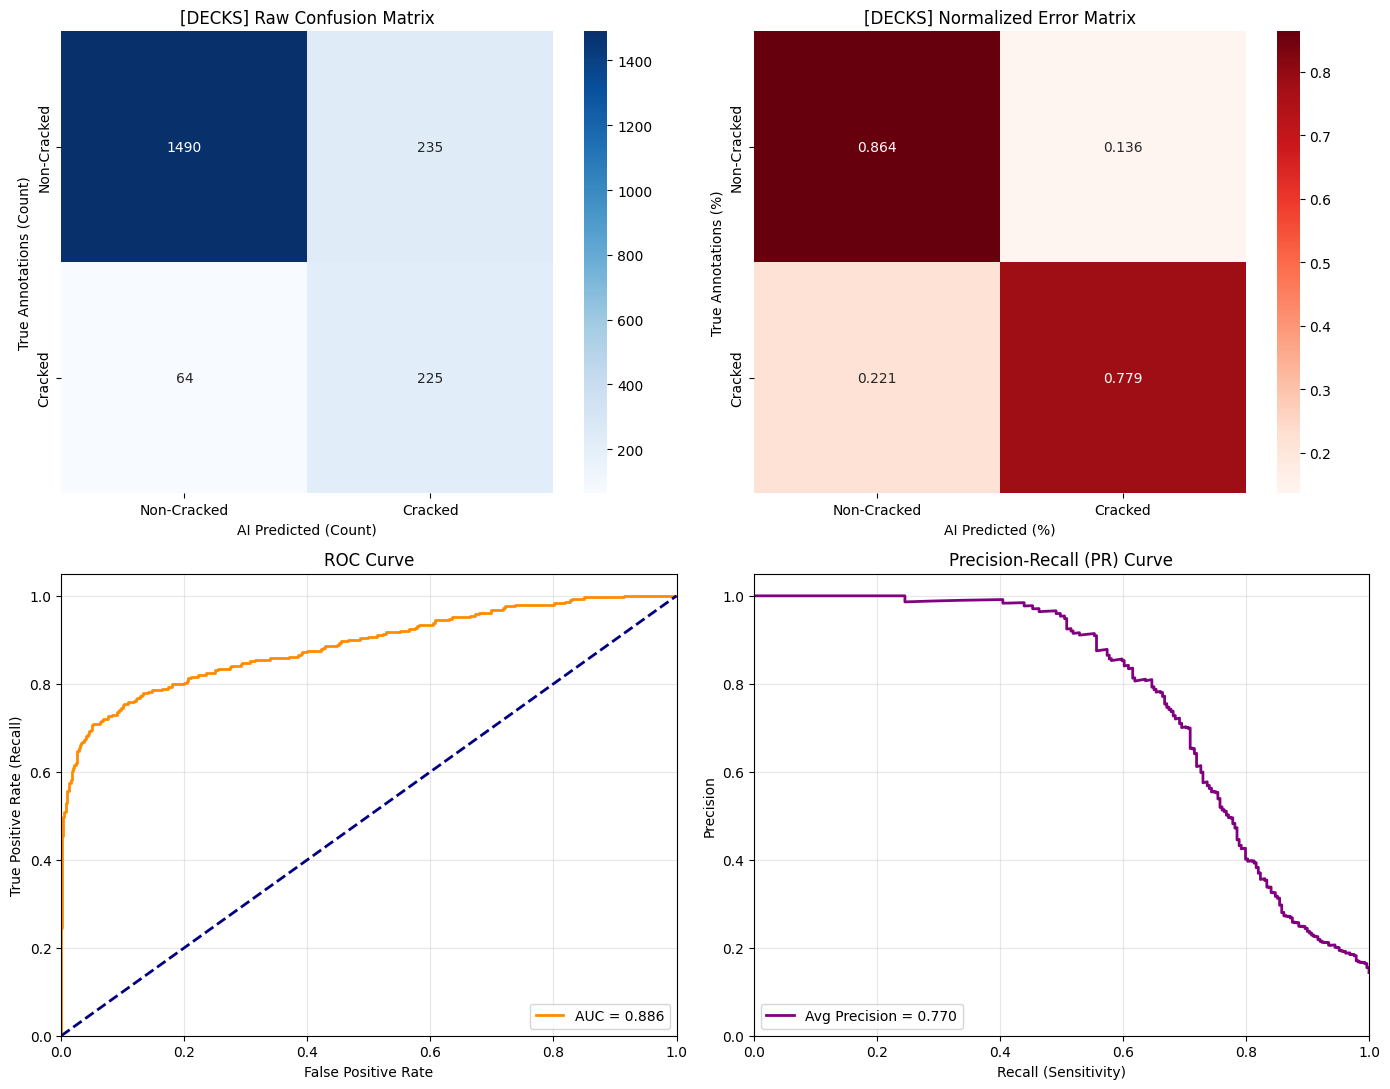


COMPREHENSIVE PERFORMANCE REPORT: BOTH DATASET
Text-based Quality Metrics Extraction:
              precision    recall  f1-score   support

 Non-Cracked     0.9525    0.9258    0.9389      3853
     Cracked     0.7021    0.7911    0.7439       852

    accuracy                         0.9014      4705
   macro avg     0.8273    0.8584    0.8414      4705
weighted avg     0.9071    0.9014    0.9036      4705



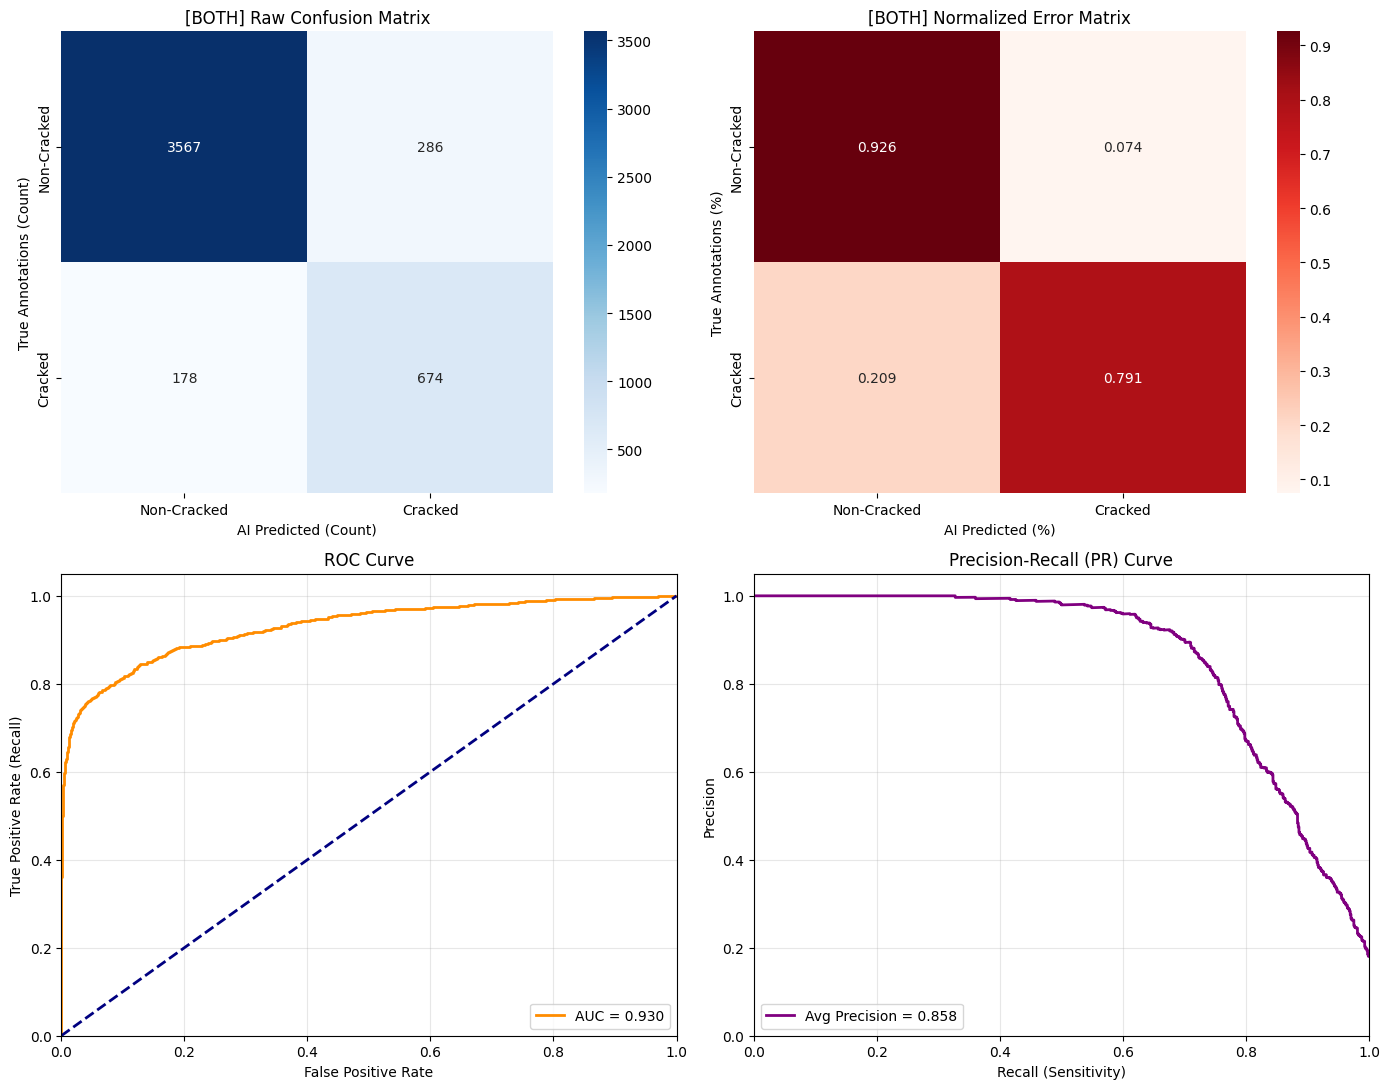

In [7]:
# Custom Threshold mapping for Safety Criteria
# Instead of default 0.50, any presence indicator slightly above 0.15 warns the engineer
CRITICAL_THRESHOLD = 0.15  

print("INITIATING FINAL PHASE CROSS-DOMAIN CHECK SUMMARY:")

for domain, configs in pipelines_artifacts.items():
    print(f"\n" + "="*65)
    print(f"COMPREHENSIVE PERFORMANCE REPORT: {domain.upper()} DATASET")
    print("="*65)
    
    # Extract robust probability distributions
    np_targets, np_probs = load_and_evaluate(configs["model_path"], configs["test_dl"], device)
    
    # Enforce strict safety thresholds 
    np_preds = (np_probs >= CRITICAL_THRESHOLD).astype(int)
    
    # 1. Print Standard Classification Report first
    print("Text-based Quality Metrics Extraction:")
    print(classification_report(np_targets, np_preds, target_names=['Non-Cracked', 'Cracked'], digits=4))
    
    # 2. Render highly detailed 2x2 graphics engine
    plot_comprehensive_analytics(np_targets, np_probs, np_preds, domain)
